# Lesson 10 — CAPSTONE: Full Production Agent
## "Database QA Assistant with Human-in-the-Loop + Memory"

This notebook combines **everything** from Lessons 1–9 into one real-world application.

## What this agent can do
- ✅ Answer **natural language questions** about a database
- ✅ **Write and execute SQL** queries automatically
- ✅ **Pause for human approval** before any data modification
- ✅ **Remember context** across turns (per-user sessions)
- ✅ **Stream** responses token by token
- ✅ **Log** every step for debugging

## Architecture
```
User Question
     ↓
[SUPERVISOR] — routes to specialist or FINISH
     ├── db_agent      — SQL queries (read-only, ReAct loop)
     ├── analyst       — statistics and summaries
     ├── human_review  — pauses for approval (HITL)
     └── FINISH        — done

All specialists report back → SUPERVISOR → FINISH
```

## Lessons used
| Lesson | Feature used |
|--------|-------------|
| 1–2 | StateGraph, conditional edges |
| 3 | MessagesState, Ollama |
| 4 | @tool, ToolNode, ReAct loop |
| 5 | Supervisor + specialist pattern |
| 6 | SQLite database tools |
| 7 | interrupt(), Command(resume=) |
| 8 | MemorySaver, thread_id |
| 9 | Logging, structured output, recursion limit |

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
from config import get_ollama_model

import sqlite3, os, logging, json
from typing import Annotated
from typing_extensions import TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("capstone")
print("Imports done!")

Imports done!


## Step 1 — Build the Database

In [2]:
DB_PATH = "capstone_company.db"

conn = sqlite3.connect(DB_PATH)
conn.executescript("""
    CREATE TABLE IF NOT EXISTS departments (id INTEGER PRIMARY KEY, name TEXT, location TEXT, budget REAL);
    CREATE TABLE IF NOT EXISTS employees  (id INTEGER PRIMARY KEY, name TEXT, department_id INTEGER, salary REAL, hire_date TEXT, job_title TEXT);
    CREATE TABLE IF NOT EXISTS sales      (id INTEGER PRIMARY KEY, employee_id INTEGER, product TEXT, amount REAL, sale_date TEXT);

    INSERT OR IGNORE INTO departments VALUES (1,'Engineering','New York',500000),(2,'Sales','Chicago',300000),(3,'Marketing','Los Angeles',200000);
    INSERT OR IGNORE INTO employees   VALUES
        (1,'Alice Johnson',1,95000,'2020-03-15','Senior Engineer'),
        (2,'Bob Smith',1,85000,'2021-07-01','Engineer'),
        (3,'Carol White',2,72000,'2019-11-20','Sales Manager'),
        (4,'David Brown',2,65000,'2022-01-10','Sales Rep'),
        (5,'Eve Davis',2,67000,'2021-05-15','Sales Rep'),
        (6,'Frank Miller',3,78000,'2020-08-30','Marketing Lead');
    INSERT OR IGNORE INTO sales VALUES
        (1,3,'Laptop Pro',6499.95,'2024-01-15'),(2,4,'Mouse',599.80,'2024-01-20'),
        (3,5,'Monitor',4799.92,'2024-02-05'),(4,3,'Desk',1499.97,'2024-02-10'),
        (5,4,'Chair',3499.90,'2024-03-01'),(6,5,'Laptop Pro',9099.93,'2024-03-15');
""")
conn.commit(); conn.close()
print(f"✅ Database ready: {DB_PATH}")

✅ Database ready: capstone_company.db


## Step 2 — Define Tools

In [3]:
@tool
def list_tables() -> str:
    """List all database tables. Call this first."""
    conn = sqlite3.connect(DB_PATH)
    t = [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
    conn.close(); return "Tables: " + ", ".join(t)

@tool
def describe_table(table_name: str) -> str:
    """Get schema + sample rows for a table. Use before writing SQL."""
    conn = sqlite3.connect(DB_PATH)
    cols   = conn.execute(f"PRAGMA table_info({table_name})").fetchall()
    sample = conn.execute(f"SELECT * FROM {table_name} LIMIT 2").fetchall()
    conn.close()
    return f"Columns: {', '.join(c[1] for c in cols)}\nSample: {sample}"

@tool
def run_sql(query: str) -> str:
    """Execute a SELECT query. READ-ONLY. Use JOINs when needed. Limit 20 rows."""
    if not query.strip().upper().startswith("SELECT"):
        return "ERROR: Only SELECT allowed. Use request_data_change for modifications."
    conn = sqlite3.connect(DB_PATH)
    try:
        cur  = conn.execute(query)
        rows = cur.fetchmany(20)
        cols = [d[0] for d in cur.description]
        if not rows: return "No results."
        return f"Cols: {', '.join(cols)}\n" + "\n".join("  " + " | ".join(str(v) for v in r) for r in rows)
    except sqlite3.Error as e:
        return f"SQL Error: {e}"
    finally: conn.close()

@tool
def get_summary_statistics(table_name: str, numeric_column: str) -> str:
    """Get min/max/avg/sum for a numeric column."""
    conn = sqlite3.connect(DB_PATH)
    try:
        r = conn.execute(f"SELECT MIN({numeric_column}), MAX({numeric_column}), AVG({numeric_column}), SUM({numeric_column}) FROM {table_name}").fetchone()
        return f"{table_name}.{numeric_column}: min={r[0]:.2f}, max={r[1]:.2f}, avg={r[2]:.2f}, sum={r[3]:.2f}"
    except Exception as e:
        return f"Error: {e}"
    finally: conn.close()

@tool
def request_data_change(table: str, operation: str, details: str) -> str:
    """Request a data change (INSERT/UPDATE/DELETE). ALWAYS requires human approval."""
    return f"Data change requested: {operation} on '{table}'. Details: {details}. Awaiting human approval."

read_tools = [list_tables, describe_table, run_sql, get_summary_statistics]
all_tools  = read_tools + [request_data_change]
print(f"✅ {len(all_tools)} tools defined")

✅ 5 tools defined


## Step 3 — State, LLMs, and Nodes

In [4]:
class CapstoneState(TypedDict):
    messages:   Annotated[list, add_messages]
    user_id:    str
    next_agent: str


llm     = ChatOllama(model=get_ollama_model(), temperature=0)
db_llm  = llm.bind_tools(all_tools)


# --- Supervisor ---
SUP_PROMPT = """Route to: db_agent (SQL questions), analyst (stats/trends), human_review (data changes), FINISH (done).
Respond ONLY: {"next": "db_agent"} or {"next": "analyst"} or {"next": "human_review"} or {"next": "FINISH"}"""

def supervisor(state: CapstoneState) -> dict:
    logger.info(f"SUPERVISOR | user={state['user_id']}")
    msgs = [SystemMessage(content=SUP_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    try:
        raw  = resp.content
        next_agent = json.loads(raw[raw.find("{"):raw.rfind("}")+1]).get("next", "FINISH")
    except: next_agent = "FINISH"
    logger.info(f"SUPERVISOR → {next_agent}")
    return {"next_agent": next_agent}

def route_supervisor(state): 
    n = state.get("next_agent", "FINISH")
    return n if n in ["db_agent", "analyst", "human_review"] else "__end__"


# --- DB Agent ---
DB_PROMPT = """Expert SQL analyst. ALWAYS: 1) list_tables 2) describe_table 3) run_sql. Never guess column names."""

def db_agent(state: CapstoneState) -> dict:
    logger.info("DB_AGENT | start")
    tool_node = ToolNode(read_tools)
    msgs = [SystemMessage(content=DB_PROMPT)] + state["messages"]
    for _ in range(6):
        resp = db_llm.invoke(msgs)
        msgs.append(resp)
        if not (hasattr(resp, "tool_calls") and resp.tool_calls): break
        msgs.extend(tool_node.invoke({"messages": msgs})["messages"])
    return {"messages": msgs[len(state["messages"])+1:]}


# --- Analyst ---
def analyst(state: CapstoneState) -> dict:
    logger.info("ANALYST | start")
    a_llm     = llm.bind_tools([run_sql, get_summary_statistics])
    tool_node = ToolNode([run_sql, get_summary_statistics])
    msgs = [SystemMessage(content="Data analyst. Use tools. Give insights.")] + state["messages"]
    for _ in range(4):
        resp = a_llm.invoke(msgs)
        msgs.append(resp)
        if not (hasattr(resp, "tool_calls") and resp.tool_calls): break
        msgs.extend(tool_node.invoke({"messages": msgs})["messages"])
    return {"messages": msgs[len(state["messages"])+1:]}


# --- Human Review (HITL) ---
def human_review(state: CapstoneState) -> dict:
    logger.info("HUMAN_REVIEW | interrupting")
    req = state["messages"][-1].content if state["messages"] else "Unknown"
    decision = interrupt({"message": "Data change requested. Approve or reject?", "request": req})
    if str(decision).lower() == "approve":
        return {"messages": [AIMessage(content="✅ Data change approved and executed.")]}
    return {"messages": [AIMessage(content="❌ Data change rejected. No modifications made.")]}


print("✅ All nodes defined")

✅ All nodes defined


## Step 4 — Build and Compile the Capstone Graph

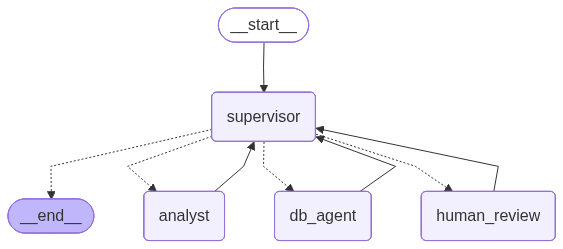

In [5]:
builder = StateGraph(CapstoneState)

builder.add_node("supervisor",   supervisor)
builder.add_node("db_agent",     db_agent)
builder.add_node("analyst",      analyst)
builder.add_node("human_review", human_review)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor", route_supervisor,
    {"db_agent": "db_agent", "analyst": "analyst", "human_review": "human_review", "__end__": END}
)
builder.add_edge("db_agent",     "supervisor")
builder.add_edge("analyst",      "supervisor")
builder.add_edge("human_review", "supervisor")

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph compiled! (viz: {e})")

## Step 5 — Helper: Ask Function

In [6]:
def ask(question: str, user_id: str = "notebook-user", thread: str = None):
    t = thread or f"cap-{user_id}"
    config = {"configurable": {"thread_id": t}, "recursion_limit": 25}
    print(f"\n{'='*55}")
    print(f"❓ {question}")
    print('='*55)
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)], "user_id": user_id, "next_agent": ""},
        config=config
    )
    # Handle HITL interrupt
    state = graph.get_state(config)
    if state.next:
        for task in state.tasks:
            if task.interrupts:
                print(f"\n⚠️  {task.interrupts[0].value['message']}")
                decision = input("approve/reject: ").strip().lower()
                result = graph.invoke(Command(resume=decision), config=config)
    # Print last AI message
    for msg in reversed(result["messages"]):
        if isinstance(msg, AIMessage):
            print(f"\n💬 {msg.content}")
            break
    return result

## Step 6 — Test: Database Questions

In [8]:
ask("How many employees are in each department?")

12:46:52 [INFO] SUPERVISOR | user=notebook-user



❓ How many employees are in each department?


12:46:53 [INFO] HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
12:47:01 [INFO] SUPERVISOR → human_review
12:47:01 [INFO] HUMAN_REVIEW | interrupting



⚠️  Data change requested. Approve or reject?


12:47:07 [INFO] HUMAN_REVIEW | interrupting
12:47:07 [INFO] SUPERVISOR | user=notebook-user
12:47:07 [INFO] HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
12:47:09 [INFO] SUPERVISOR → FINISH



💬 ✅ Data change approved and executed.


{'messages': [HumanMessage(content='How many employees are in each department?', additional_kwargs={}, response_metadata={}, id='61ec79e0-7818-4f46-9eae-b51dafb20eed'),
  AIMessage(content='The tools provided do not include a function to retrieve department counts directly. To answer this question, I would need access to a database table that includes department information. Could you provide the necessary table or column names for this query?', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-04-28T09:46:27.0995252Z', 'done': True, 'done_reason': 'stop', 'total_duration': 19737999600, 'load_duration': 190425500, 'prompt_eval_count': 218, 'prompt_eval_duration': 1823774000, 'eval_count': 496, 'eval_duration': 17500485500, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019dd37b-507d-7643-9f17-0ff95f0db3f0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 496, 'total_t

In [9]:
ask("Who are the top 3 highest-paid employees?")

12:48:13 [INFO] SUPERVISOR | user=notebook-user



❓ Who are the top 3 highest-paid employees?


12:48:13 [INFO] HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
12:48:22 [INFO] SUPERVISOR → analyst
12:48:22 [INFO] ANALYST | start
12:48:26 [INFO] HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
12:48:38 [INFO] SUPERVISOR | user=notebook-user
12:48:40 [INFO] HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
12:48:40 [INFO] SUPERVISOR → FINISH



💬 I don't have access to a database table that includes employee salaries or a function to retrieve a sorted list of top salaries. Could you provide the necessary table or column names for this query?


{'messages': [HumanMessage(content='How many employees are in each department?', additional_kwargs={}, response_metadata={}, id='61ec79e0-7818-4f46-9eae-b51dafb20eed'),
  AIMessage(content='The tools provided do not include a function to retrieve department counts directly. To answer this question, I would need access to a database table that includes department information. Could you provide the necessary table or column names for this query?', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-04-28T09:46:27.0995252Z', 'done': True, 'done_reason': 'stop', 'total_duration': 19737999600, 'load_duration': 190425500, 'prompt_eval_count': 218, 'prompt_eval_duration': 1823774000, 'eval_count': 496, 'eval_duration': 17500485500, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019dd37b-507d-7643-9f17-0ff95f0db3f0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 496, 'total_t

In [ ]:
ask("What is the total sales revenue by employee? Show names.")

## Step 7 — Test: Multi-Turn Memory

Use the same `thread` to maintain conversation history.

In [ ]:
# Turn 1 — establish context
ask("Focus on the Sales department. Who is in it?", thread="memory-test")

In [ ]:
# Turn 2 — follow-up (agent should remember we're discussing Sales)
ask("What is the average salary of the people you just listed?", thread="memory-test")

## Step 8 — Test: Human-in-the-Loop (Data Change)

When you ask for a data modification, the agent will request approval.

In [ ]:
# This will trigger the human_review interrupt
# You'll be prompted to type 'approve' or 'reject'
ask("Please add a new employee named 'Sara Ahmed' to the Engineering department with salary 88000.")

## Step 9 — Streaming Mode

In [ ]:
config = {"configurable": {"thread_id": "stream-test"}, "recursion_limit": 25}
print("Streaming answer...\n")

for event in graph.stream(
    {"messages": [HumanMessage(content="What is the average salary across all employees?")],
     "user_id": "stream-user", "next_agent": ""},
    config=config,
    stream_mode="values"
):
    msgs = event.get("messages", [])
    if msgs and isinstance(msgs[-1], AIMessage) and msgs[-1].content:
        print(f"[update] {msgs[-1].content[:80]}")

## 🎉 Congratulations — Full Curriculum Complete!

| Lesson | Topic | Status |
|--------|-------|--------|
| 1 | StateGraph, nodes, edges | ✅ |
| 2 | Conditional edges | ✅ |
| 3 | Chatbot with memory | ✅ |
| 4 | ReAct agent with tools | ✅ |
| 5 | Multi-agent supervisor | ✅ |
| 6 | Database agent (NL→SQL) | ✅ |
| 7 | Human-in-the-loop | ✅ |
| 8 | Persistent memory | ✅ |
| 9 | Production best practices | ✅ |
| 10 | Capstone (everything combined) | ✅ |

## 🏋️ Final Challenge
Extend the capstone with:
1. A **new `hr_agent`** specialist that answers HR questions (job titles, hire dates, department assignments)
2. A **`report_agent`** that generates a formatted markdown summary report
3. **`SqliteSaver`** instead of `MemorySaver` for true persistence
4. **Input validation** on every user query before it enters the graph

In [ ]:
# Your final challenge here
